In [20]:
import tensorflow as tf, numpy as np, matplotlib.pyplot as plt
from tensorflow.keras import layers, Model

In [21]:
(x_train, _), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.
x_train = x_train[..., None]
x_test = x_test[..., None]

In [22]:
class Encoder(Model):
    def __init__(self, latent):
        super().__init__()
        self.f = layers.Flatten()
        self.d1 = layers.Dense(512, activation='relu')
        self.dr1 = layers.Dropout(0.1)
        self.d2 = layers.Dense(256, activation='relu')
        self.dr2 = layers.Dropout(0.1)
        self.d3 = layers.Dense(128, activation='relu')
        self.mu = layers.Dense(latent)
        self.logvar = layers.Dense(latent)
    def call(self, x):
        h = self.dr2(self.d2(self.dr1(self.d1(self.f(x)))))
        mu = self.mu(h)
        lv = self.logvar(h)
        eps = tf.random.normal(tf.shape(mu))
        z = mu + tf.exp(0.5 * lv) * eps
        return z, mu, lv

In [23]:
class Decoder(Model):
    def __init__(self, latent):
        super().__init__()
        self.net = tf.keras.Sequential([
            layers.Input((latent,)),
            layers.Dense(128, activation='relu'),
            layers.Dense(256, activation='relu'),
            layers.Dense(512, activation='relu'),
            layers.Dense(784, activation='sigmoid'),
            layers.Reshape((28, 28, 1))
        ])
    def call(self, z): return self.net(z)

In [24]:
class VAE(Model):
    def __init__(self, latent):
        super().__init__()
        self.encoder = Encoder(latent)
        self.decoder = Decoder(latent)
        self.rt = tf.keras.metrics.Mean()
        self.kt = tf.keras.metrics.Mean()
        self.et = tf.keras.metrics.Mean()
    @property
    def metrics(self): return [self.rt, self.kt, self.et]
    def train_step(self, x):
        with tf.GradientTape() as tape:
            z, mu, lv = self.encoder(x)
            xr = self.decoder(z)
            rec = tf.reduce_mean(tf.reduce_sum(tf.keras.losses.binary_crossentropy(x, xr), axis=(1, 2)))
            kl = tf.reduce_mean(-0.5 * tf.reduce_sum(1 + lv - tf.square(mu) - tf.exp(lv), axis=1))
            loss = rec + kl
        g = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(g, self.trainable_weights))
        self.rt.update_state(rec); self.kt.update_state(kl); self.et.update_state(loss)
        return {"reconstruction": self.rt.result(), "kl": self.kt.result(), "elbo": self.et.result()}


Latent dimension: 2
Epoch 1/20


c:\Users\Reaper\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\layer.py:431: UserWarning: `build()` was called on layer 'encoder_6', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - elbo: 294.4302 - kl: 6.0612 - reconstruction: 288.3691
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - elbo: 269.2711 - kl: 6.0319 - reconstruction: 263.2393
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - elbo: 265.4818 - kl: 6.0460 - reconstruction: 259.4357
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - elbo: 263.6968 - kl: 6.0565 - reconstruction: 257.6404
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - elbo: 262.2082 - kl: 6.0978 - reconstruction: 256.1104
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - elbo: 261.3114 - kl: 6.1641 - reconstruction: 255.1474
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - elbo: 260.3023 - kl: 6.2147 - reconstruction: 254.0876
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - elbo: 259.6085 - kl: 6.2459 - reconstruction: 253.3625
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - elbo: 258.9264 - kl: 6.2951 - reconstruction: 252.6312
Epoch 10/20
469/469 ━━━━━━━━━━

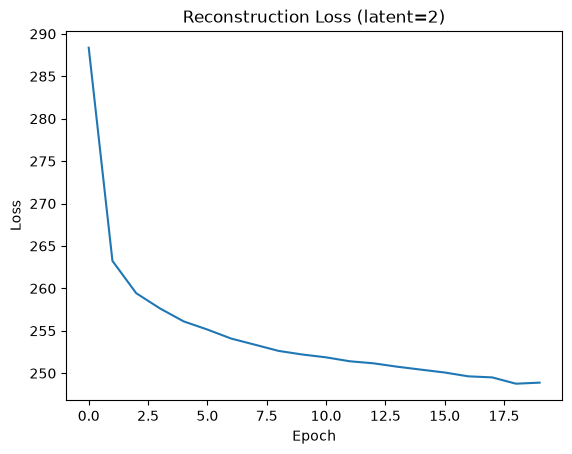

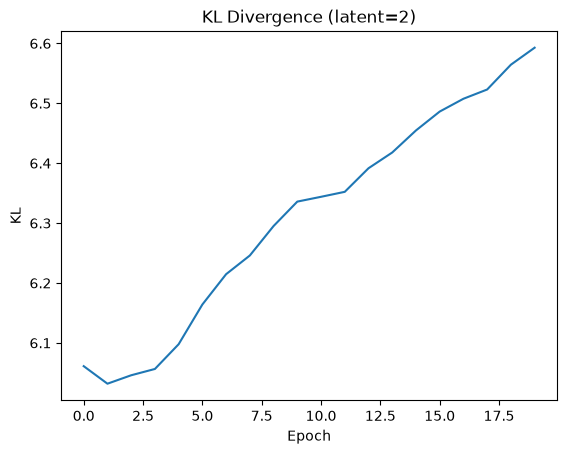

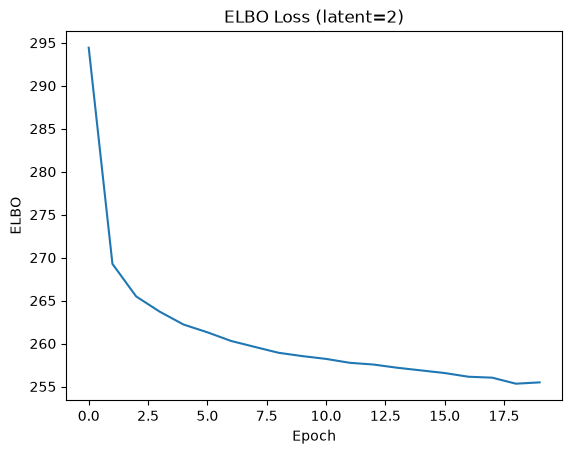

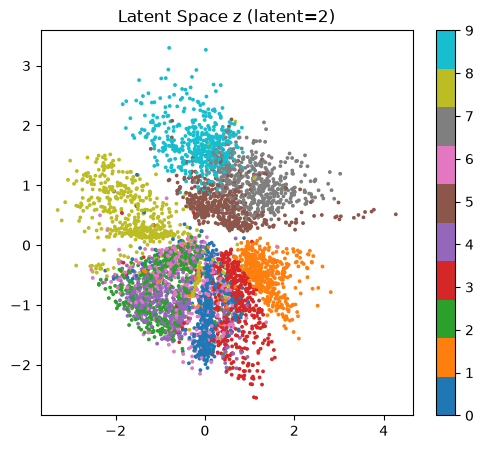

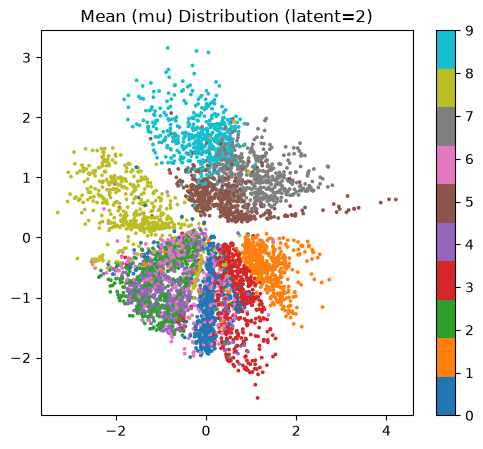

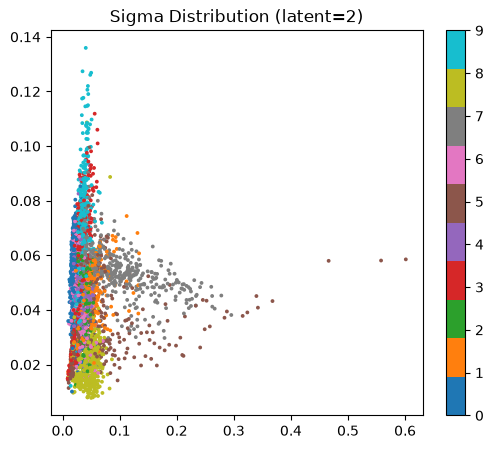

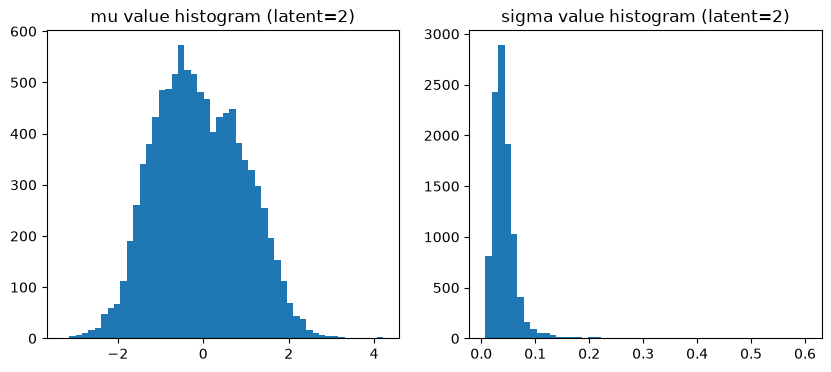

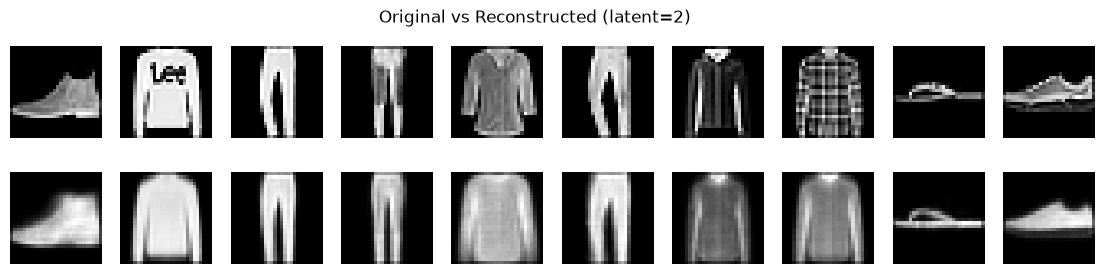

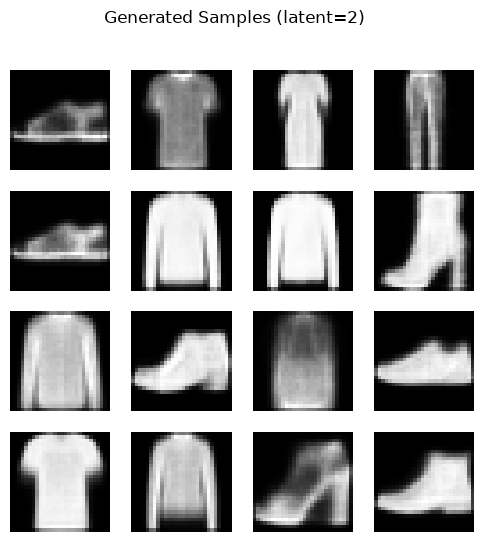

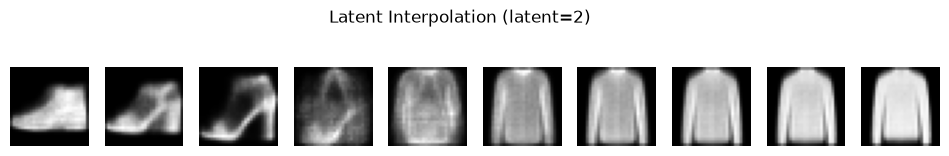


Latent dimension: 4
Epoch 1/20


c:\Users\Reaper\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\layer.py:431: UserWarning: `build()` was called on layer 'encoder_7', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - elbo: 282.8490 - kl: 8.0278 - reconstruction: 274.8210
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - elbo: 253.1191 - kl: 8.9728 - reconstruction: 244.1463
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - elbo: 249.7603 - kl: 9.1238 - reconstruction: 240.6365
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - elbo: 248.0164 - kl: 9.2238 - reconstruction: 238.7926
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - elbo: 246.9763 - kl: 9.2836 - reconstruction: 237.6927
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - elbo: 246.0406 - kl: 9.3468 - reconstruction: 236.6936
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - elbo: 245.4271 - kl: 9.3837 - reconstruction: 236.0434
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - elbo: 244.9032 - kl: 9.4292 - reconstruction: 235.4741
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - elbo: 244.4130 - kl: 9.4846 - reconstruction: 234.9285
Epoch 10/20
469/469 ━━━━━━━━━━

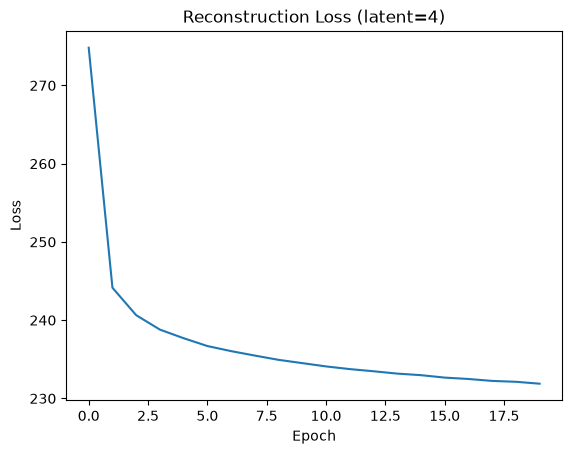

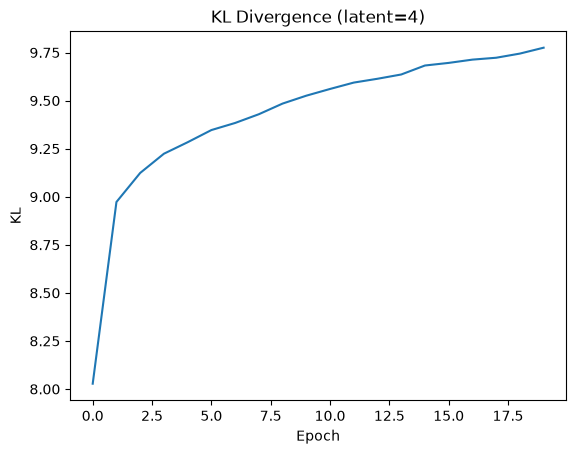

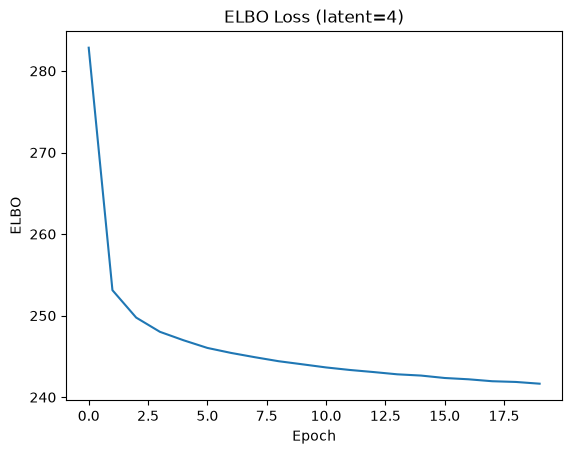

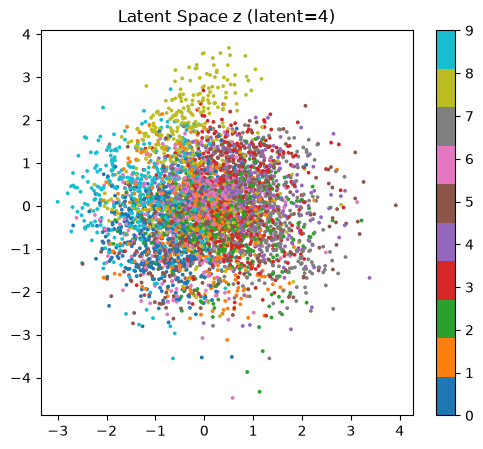

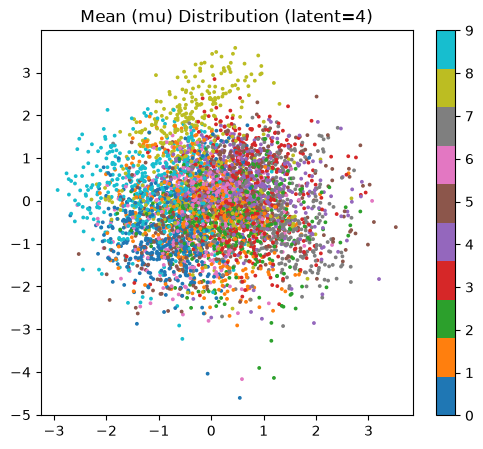

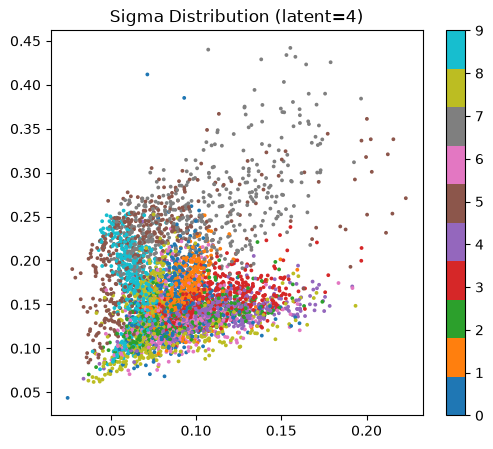

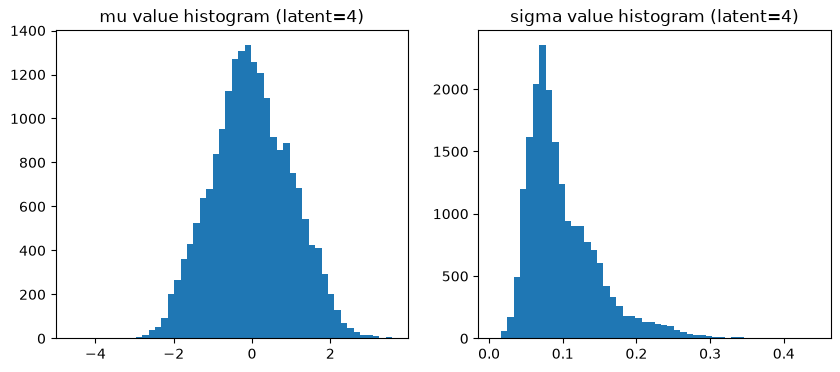

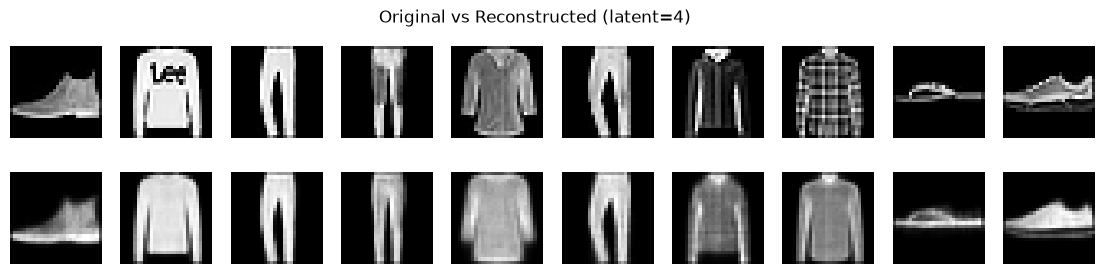

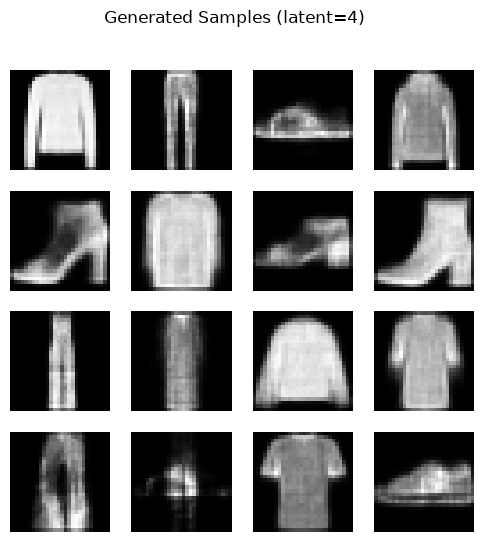

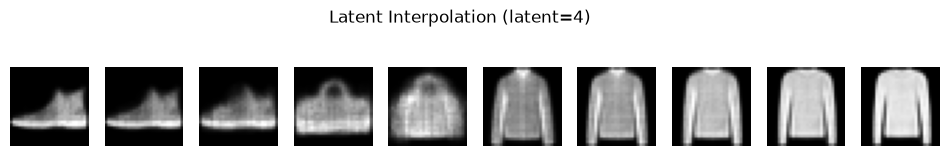


Latent dimension: 6
Epoch 1/20


c:\Users\Reaper\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\layer.py:431: UserWarning: `build()` was called on layer 'encoder_8', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - elbo: 282.2326 - kl: 8.7968 - reconstruction: 273.4359
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - elbo: 252.5313 - kl: 9.7698 - reconstruction: 242.7616
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - elbo: 248.7104 - kl: 10.0466 - reconstruction: 238.6639
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - elbo: 246.7691 - kl: 10.1687 - reconstruction: 236.6004
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - elbo: 245.5072 - kl: 10.2908 - reconstruction: 235.2164
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - elbo: 244.4976 - kl: 10.3875 - reconstruction: 234.1102
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - elbo: 243.6706 - kl: 10.4603 - reconstruction: 233.2103
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - elbo: 243.0312 - kl: 10.5408 - reconstruction: 232.4904
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - elbo: 242.4472 - kl: 10.6119 - reconstruction: 231.8353
Epoch 10/20
469/469 ━━━

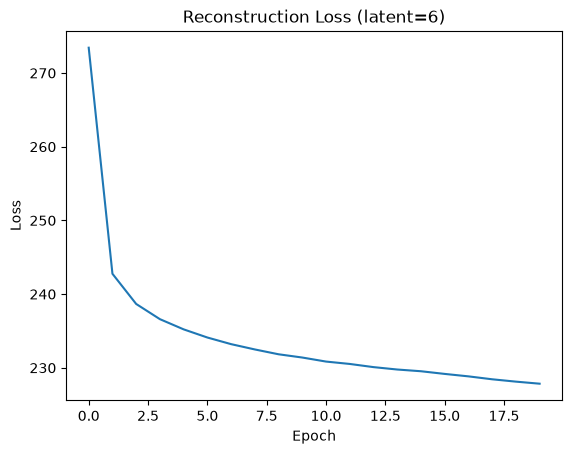

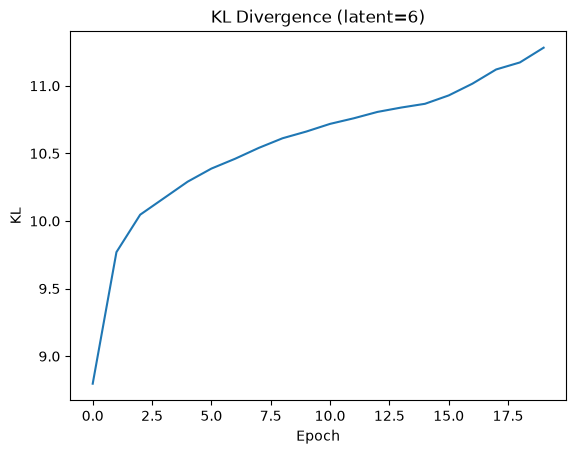

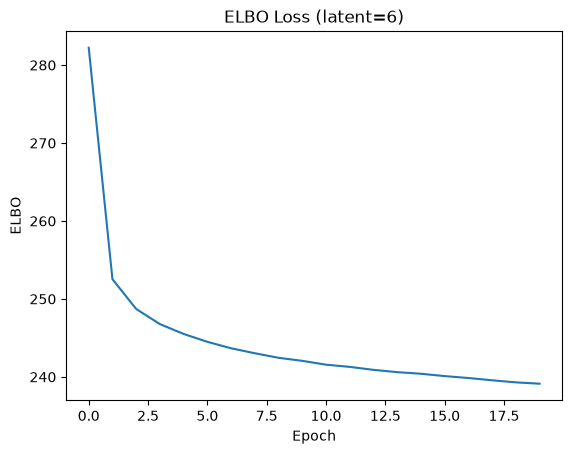

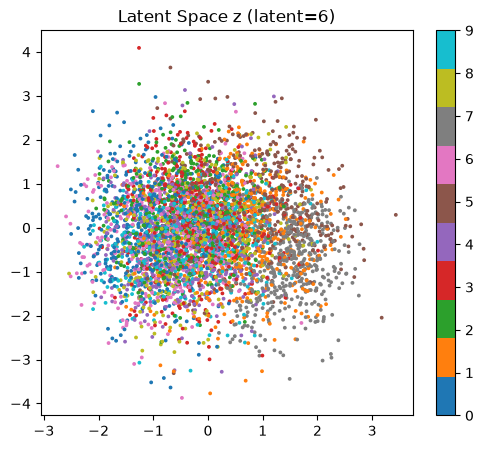

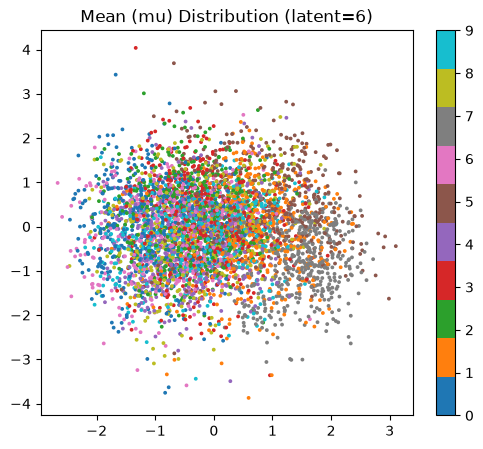

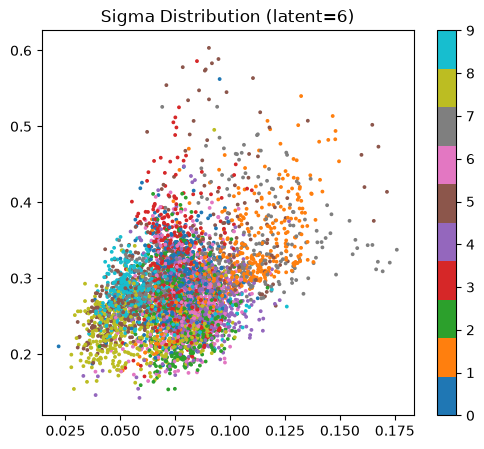

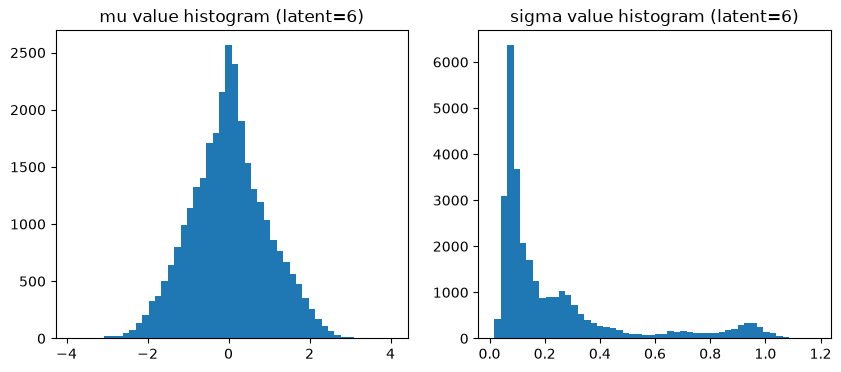

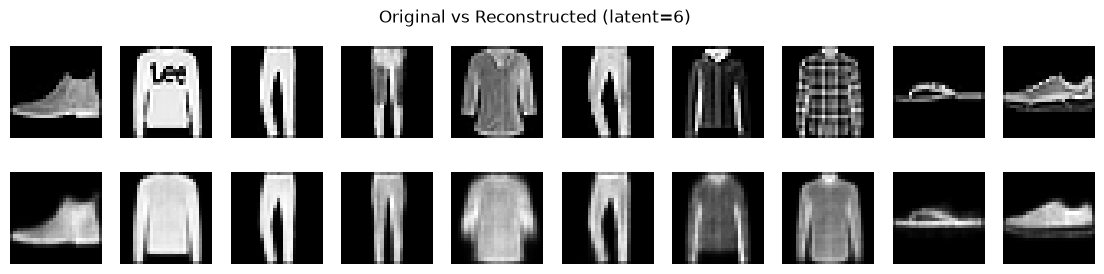

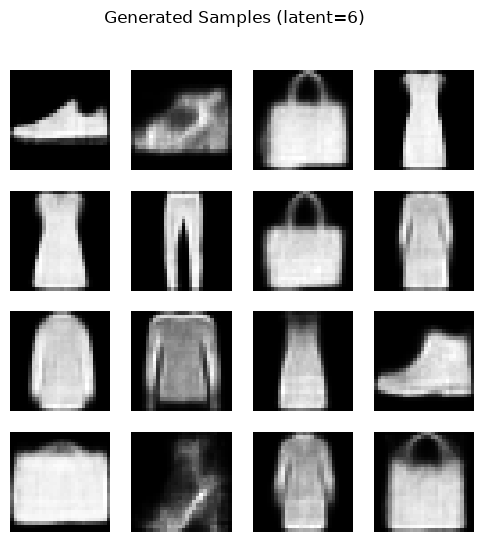

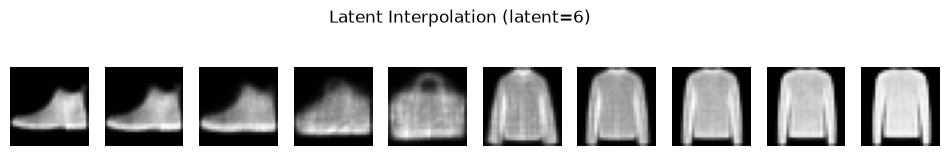


Latent dimension: 8
Epoch 1/20


c:\Users\Reaper\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\layer.py:431: UserWarning: `build()` was called on layer 'encoder_9', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - elbo: 282.7571 - kl: 9.7283 - reconstruction: 273.0287
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - elbo: 251.7594 - kl: 10.8454 - reconstruction: 240.9142
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - elbo: 247.7089 - kl: 11.1217 - reconstruction: 236.5871
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - elbo: 245.7766 - kl: 11.2710 - reconstruction: 234.5055
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - elbo: 244.1741 - kl: 11.4054 - reconstruction: 232.7685
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - elbo: 243.2333 - kl: 11.4981 - reconstruction: 231.7352
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - elbo: 242.4291 - kl: 11.5872 - reconstruction: 230.8418
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - elbo: 241.8314 - kl: 11.6467 - reconstruction: 230.1847
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - elbo: 241.1887 - kl: 11.7282 - reconstruction: 229.4606
Epoch 10/20
469/469 ━━

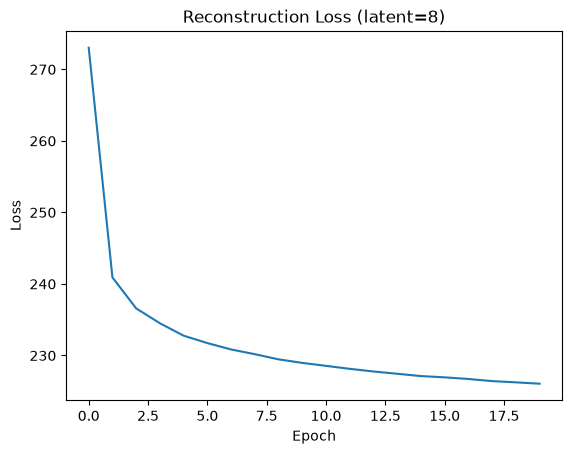

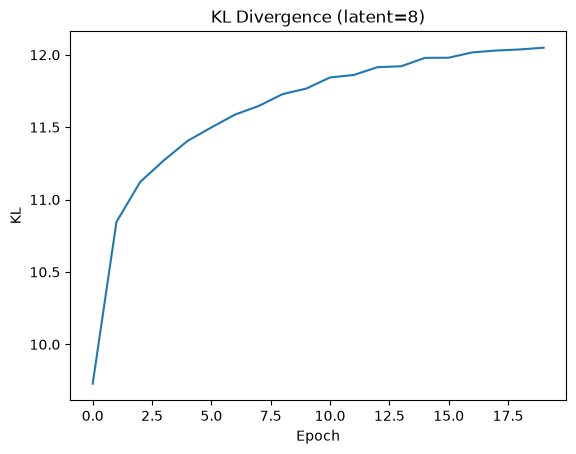

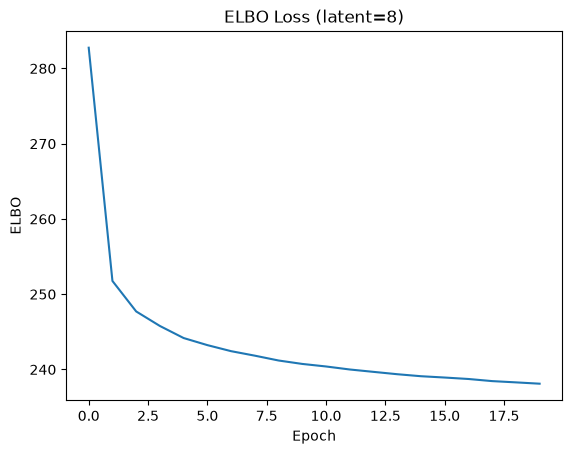

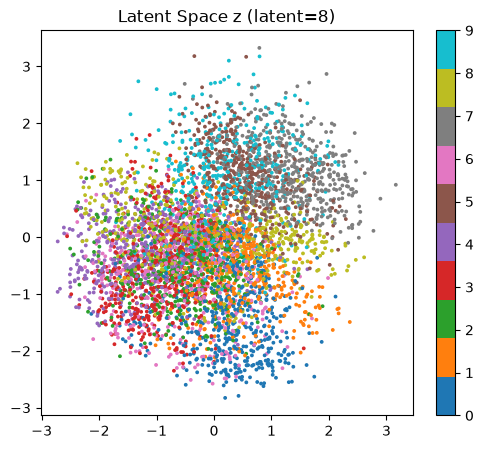

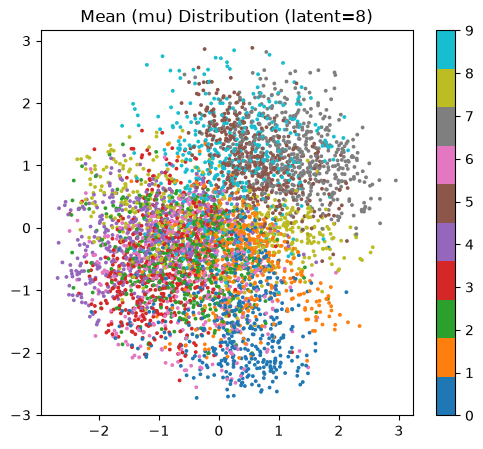

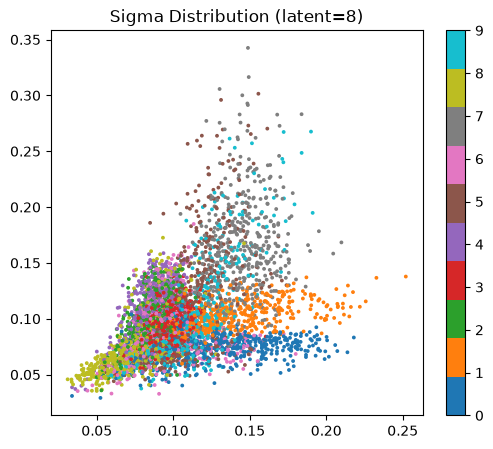

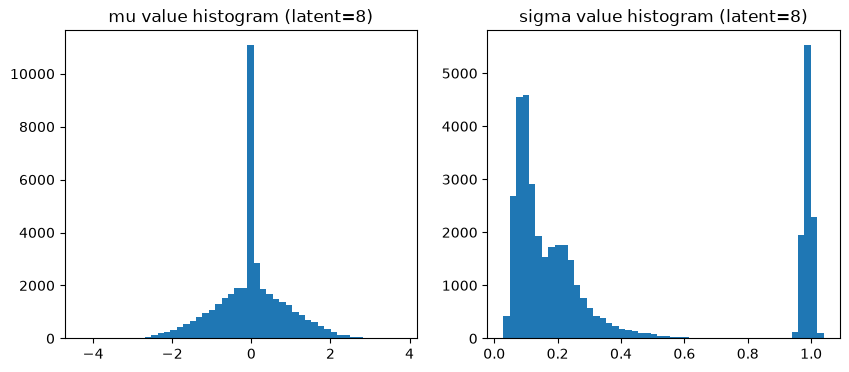

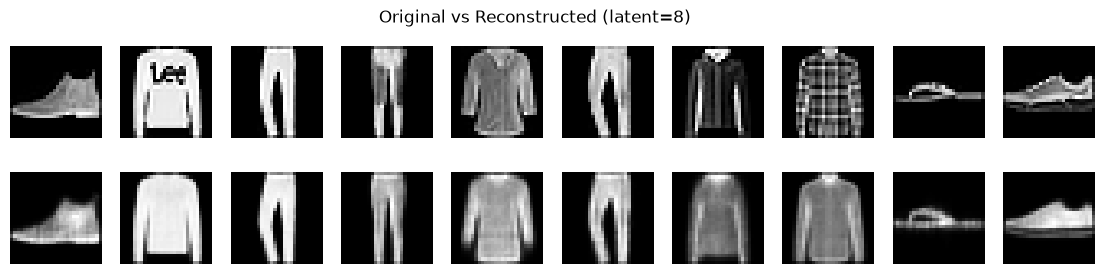

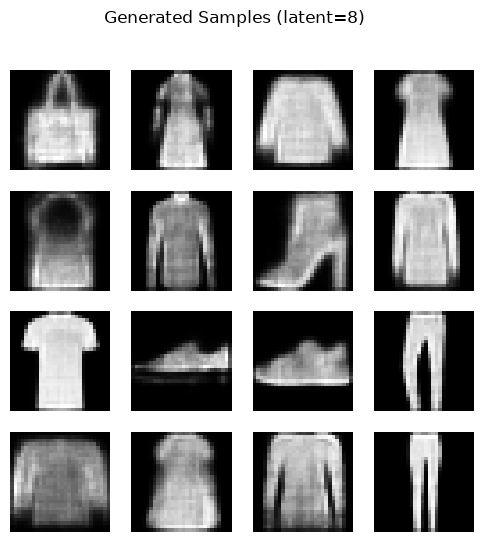

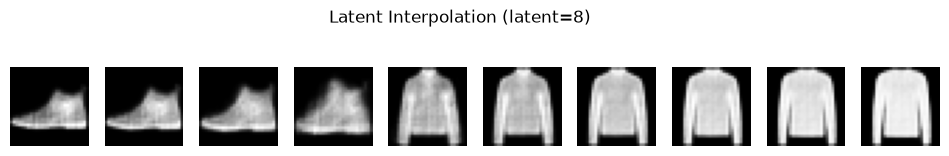

In [25]:
results = {}
models = {}

for latent in [2, 4, 6, 8]:
    print("\nLatent dimension:", latent)
    vae = VAE(latent)
    vae.compile(optimizer=tf.keras.optimizers.Adam(1e-3))
    h = vae.fit(x_train, epochs=20, batch_size=128, verbose=1)
    models[latent] = vae

    enc_params = vae.encoder.count_params()
    dec_params = vae.decoder.count_params()
    total_params = enc_params + dec_params
    compression = 784 / latent
    print("Encoder params:", enc_params, "Decoder params:", dec_params,
          "Total:", total_params, "Compression ratio:", compression)

    results[latent] = {
        "history": h.history,
        "enc_params": enc_params,
        "dec_params": dec_params,
        "total_params": total_params,
        "compression": compression
    }

    plt.figure(); plt.plot(h.history['reconstruction']); plt.title(f"Reconstruction Loss (latent={latent})")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.show()

    plt.figure(); plt.plot(h.history['kl']); plt.title(f"KL Divergence (latent={latent})")
    plt.xlabel("Epoch"); plt.ylabel("KL"); plt.show()

    plt.figure(); plt.plot(h.history['elbo']); plt.title(f"ELBO Loss (latent={latent})")
    plt.xlabel("Epoch"); plt.ylabel("ELBO"); plt.show()

    z, mu, lv = vae.encoder.predict(x_test[:5000], verbose=0)
    sigma = np.exp(0.5 * lv)

    plt.figure(figsize=(6, 5))
    plt.scatter(z[:, 0], z[:, 1], c=y_test[:5000], s=3, cmap='tab10')
    plt.colorbar(); plt.title(f"Latent Space z (latent={latent})")
    plt.show()

    plt.figure(figsize=(6, 5))
    plt.scatter(mu[:, 0], mu[:, 1], c=y_test[:5000], s=3, cmap='tab10')
    plt.colorbar(); plt.title(f"Mean (mu) Distribution (latent={latent})")
    plt.show()

    plt.figure(figsize=(6, 5))
    plt.scatter(sigma[:, 0], sigma[:, 1], c=y_test[:5000], s=3, cmap='tab10')
    plt.colorbar(); plt.title(f"Sigma Distribution (latent={latent})")
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.hist(mu.flatten(), bins=50)
    plt.title(f"mu value histogram (latent={latent})")
    plt.subplot(1, 2, 2)
    plt.hist(sigma.flatten(), bins=50)
    plt.title(f"sigma value histogram (latent={latent})")
    plt.show()

    r = vae.decoder(z[:10]).numpy()
    fig, ax = plt.subplots(2, 10, figsize=(14, 3))
    fig.suptitle(f"Original vs Reconstructed (latent={latent})")
    for i in range(10):
        ax[0, i].imshow(x_test[i].squeeze(), cmap='gray'); ax[0, i].axis('off')
        ax[1, i].imshow(r[i].squeeze(), cmap='gray'); ax[1, i].axis('off')
    plt.show()

    samp = vae.decoder(tf.random.normal((16, latent)))
    plt.figure(figsize=(6, 6))
    plt.suptitle(f"Generated Samples (latent={latent})")
    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(samp[i].numpy().squeeze(), cmap='gray')
        plt.axis('off')
    plt.show()

    a, b = z[0], z[1]
    plt.figure(figsize=(12, 2))
    plt.suptitle(f"Latent Interpolation (latent={latent})")
    for i, t in enumerate(np.linspace(0, 1, 10)):
        img = vae.decoder(tf.expand_dims((1 - t) * a + t * b, 0))[0]
        plt.subplot(1, 10, i + 1)
        plt.imshow(tf.squeeze(img), cmap='gray')
        plt.axis('off')
    plt.show()

Latent | Enc Params | Dec Params | Total Params | Compression | Final Rec | Final KL | Final ELBO
2 534276 567184 1101460 392.0 248.88954162597656 6.592800140380859 255.4822998046875
4 535304 567440 1102744 196.0 231.88038635253906 9.775199890136719 241.65553283691406
6 536332 567696 1104028 130.66666666666666 227.84339904785156 11.281627655029297 239.12496948242188
8 537360 567952 1105312 98.0 226.0580596923828 12.048898696899414 238.10690307617188


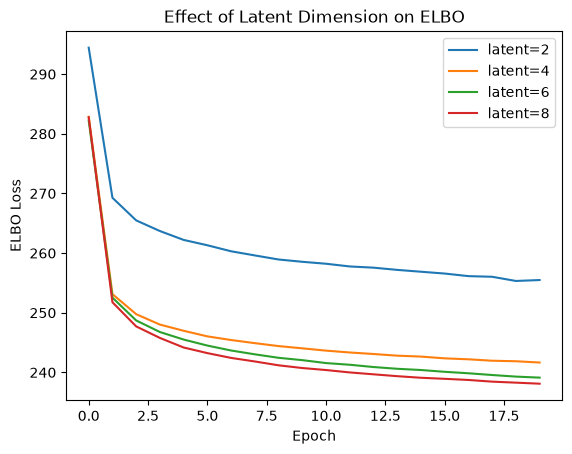

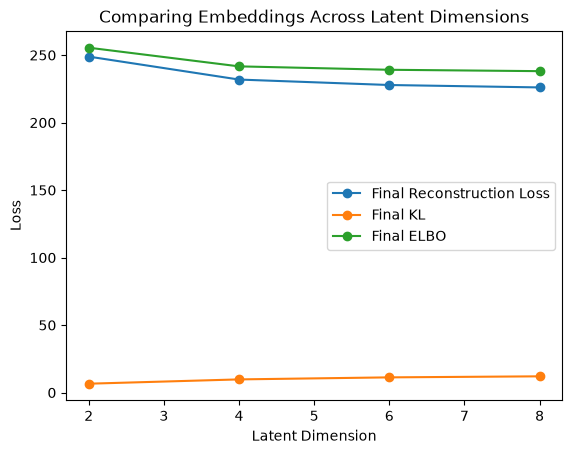

In [26]:
print("Latent | Enc Params | Dec Params | Total Params | Compression | Final Rec | Final KL | Final ELBO")
for latent, r in results.items():
    print(latent, r["enc_params"], r["dec_params"], r["total_params"], r["compression"],
          r["history"]["reconstruction"][-1], r["history"]["kl"][-1], r["history"]["elbo"][-1])

plt.figure()
for latent, r in results.items():
    plt.plot(r["history"]["elbo"], label=f"latent={latent}")
plt.xlabel("Epoch"); plt.ylabel("ELBO Loss")
plt.title("Effect of Latent Dimension on ELBO")
plt.legend(); plt.show()

plt.figure()
plt.plot(list(results.keys()), [r["history"]["reconstruction"][-1] for r in results.values()], marker='o', label="Final Reconstruction Loss")
plt.plot(list(results.keys()), [r["history"]["kl"][-1] for r in results.values()], marker='o', label="Final KL")
plt.plot(list(results.keys()), [r["history"]["elbo"][-1] for r in results.values()], marker='o', label="Final ELBO")
plt.xlabel("Latent Dimension"); plt.ylabel("Loss")
plt.title("Comparing Embeddings Across Latent Dimensions")
plt.legend(); plt.show()